### __Predicting Airbnb Listing Prices in Sydney__

--- 
## Task 3: Fit and Tune Prediction Models/ Produce predictions


### Overview

#### Breakdown of the general procedure:

✅ **1. Load Data**
- Load cleaned dataset from `data/processed/processed_train.csv`
- Split into `train` and `test` sets

✅ **2. Train Multiple Models**
- Linear Regression (baseline)
- Decision Tree (simple tree-based model)
- Random Forest (strong tree ensemble model)
- Gradient Boosting, XGBoost, LightGBM (powerful boosting methods)
- Voting Regressor (combines multiple models for better results)

✅ **3. Cross-Validation**
- Evaluate a model on multiple subsets of data

✅ **4. Hyperparameter Tuning**
- Uses GridSearchCV to find the best RandomForestRegressor parameters

✅ **5. Compare Model Performance**
- Saves R² scores for each model
- Plots bar chart of model performance

✅ **6. Save the Best Model**
- Identifies the best-performing model
- Saves it as `results/best_model.pkl`

#### Models Selection Breakdown

Since we're predicting **Airbnb listing prices** (a continuous numerical target), this is a regression problem. Based on the nature of given datasets and typical challenges in price prediction, I selected a mix of traditional ML models and ensemble learning methods to balance interpretability, predictive power, and generalization.

To assist the hyperparameters tuning process, we utilize `K-fold Cross Validation` and `RandomizedSearchCV` method. Specifically, we select important parameters and set a suitable range for them so that the Random Search can identify the best performance with optimal parameters. For the _K-fold Cross Validation_ method, its purpose is to assess how well a ML model can generalize to unseen data by training and testing on different parts of the dataset multiple times and prevent overfitting.

#### Models Selection Strategy
1. Start with a simple model (`Linear Regression`) to establish a baseline
2. Use `Decision Trees` to see how non-linear relationships improve results
3. Apply `Ensemble Methods (Random Forest, Gradient Boosting)` to enhance predictive power
4. Use `Advanced Boosting Models (XGBoost, LightGBM)` for optimized performance
5. **Fine-tune hyperparameters** using `GridSearchCV` & `Bayesian Optimization`

### Import processed data

In [24]:
# Import libraries 
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
import os

from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV, GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Models 
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, VotingRegressor
import xgboost as xgb

# Bayesian Optimization
from skopt import BayesSearchCV

In [2]:
# Set display options for better readability
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 50)

# Configure seaborn aesthetics
sns.set(style="whitegrid", palette="muted", font_scale=1.2)

Use relative paths instead of hardcoded paths to enable universal uses:

In [3]:
# Define correct file paths for loading the datasets
train_file_path = "C:/Users/haiho/GITHUB/Sydney-Airbnb-prices-prediction/data/processed/feature_engineered_train.csv"
test_file_path = "C:/Users/haiho/GITHUB/Sydney-Airbnb-prices-prediction/data/processed/feature_engineered_test.csv"

In [4]:
# Retrieve the engineered datasets
df_train = pd.read_csv(train_file_path)
df_test = pd.read_csv(test_file_path)

In [6]:
# Subset the training dataset for modelling step
X = df_train.drop(['price'],axis=1) # Features
y = df_train['price'] # Target variable

Uses `train_test_split` with `random_state=42`, ensuring reproducibility:

In [7]:
# Split into train & test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Last check for missing values or infinite values in the training set: 

In [8]:
# Check for NaN values
print("NaN values in X_train:", np.isnan(X_train).sum().sum())
print("NaN values in y_train:", np.isnan(y_train).sum())

# Check for infinite values
print("Infinite values in X_train:", np.isinf(X_train).sum().sum())
print("Infinite values in y_train:", np.isinf(y_train).sum())

NaN values in X_train: 0
NaN values in y_train: 0
Infinite values in X_train: 0
Infinite values in y_train: 0


In [9]:
# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# Define save path for storing the scaler 
save_path = "C:/Users/haiho/GITHUB/Sydney-Airbnb-prices-prediction/results/scaler.pkl"

In [ ]:
# Save scaler
joblib.dump(scaler, save_path)

### 1. Cross-Validation Function

To ensure our model generalizes well to unseen data, we use **K-Fold Cross-Validation (CV)**. This method splits the dataset into multiple folds, trains the model on some folds, and tests it on the remaining ones. 

- We define a **5-fold cross-validation strategy** using `KFold`, ensuring reproducibility with `random_state=42`.
- The `evaluate_model` function:
  - Computes **cross-validation scores** using the R² metric.
  - Prints the **mean R² score** and **standard deviation** to assess model stability.
  - Returns the mean R² score for further evaluation.

This approach helps us avoid overfitting and provides a robust estimate of model performance.


In [14]:
# Define cross-validation strategy (5-fold)
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Helper function to evaluate models 
def evaluate_model(model, X, y):
    scores = cross_val_score(model, X, y, cv=cv, scoring="r2", n_jobs=-1)
    print(f"{model.__class__.__name__}: Mean R² = {scores.mean():.3f} | Std = {scores.std():.3f}")
    return scores.mean()

### 2. Baseline Model (Linear Regression)

Multiple linear regression (MLR) uses several explanatory variables to predict the outcome of a dependent variable. The goal of multiple linear regression is to model the linear relationship between the explanatory (independent) variables and response (dependent) variables.

In [15]:
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

y_pred_lr = lin_reg.predict(X_test)
print(f"Linear Regression - R²: {r2_score(y_test, y_pred_lr):.3f}")

Linear Regression - R²: 0.928


### 3. Train Multiple Models with Cross-Validation

In this step, we train multiple regression models and evaluate their performance using **5-fold cross-validation**. 

- We define a dictionary of models, including:
  - **Decision Tree**
  - **Random Forest**
  - **Gradient Boosting**
  - **XGBoost**
  - **LightGBM**

- Each model is trained and evaluated using the previously defined `evaluate_model` function.
- The results are stored in a **DataFrame** and sorted based on the **Mean R² score**, allowing us to compare model performance.

This process helps us determine which model generalizes best to our dataset before further fine-tuning.


In [38]:
# Define multiple models with their parameters 
models = {
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42),
    "XGBoost": xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42),
}

In [19]:
# Store cross-validation results
cv_results = {name: evaluate_model(model, X_train, y_train) for name, model in models.items()}

DecisionTreeRegressor: Mean R² = 0.969 | Std = 0.009
RandomForestRegressor: Mean R² = 0.981 | Std = 0.010
GradientBoostingRegressor: Mean R² = 0.985 | Std = 0.011
XGBRegressor: Mean R² = 0.972 | Std = 0.017


In [20]:
df_cv_results = pd.DataFrame(cv_results.items(), columns=["Model", "Mean R²"]).sort_values(by="Mean R²", ascending=False)

In [21]:
df_cv_results

,Model,Mean R²
2,Gradient Boosting,0.984699
1,Random Forest,0.981422
3,XGBoost,0.971546
0,Decision Tree,0.968571


### 4. Hyperparameter Tuning with GridSearchCV

Selecting appropriate hyperparameter values for models like Random Forest, Gradient Boosting, XGBoost, and LightGBM is crucial for optimizing performance. Those ranges of values for each parameter of each model is carefully selected with a logic: 
- **Start with Defaults**: Begin with default settings to establish a baseline.
- **Incremental Testing**: Adjust one parameter at a time to observe its impact.
- **Cross-Validation**: Use techniques like GridSearchCV to systematically explore combinations.
- **Computational Resources**: Balance the depth and number of trees with available resources to manage training time.

In [26]:
param_grids = {
    "Random Forest": {
        "n_estimators": [100, 300, 500],
        "max_depth": [10, 20, None],
        "min_samples_split": [2, 5, 10],
    },
    "Gradient Boosting": {
        "n_estimators": [100, 300, 500],
        "learning_rate": [0.01, 0.1, 0.2],
        "max_depth": [3, 5, 7],
    },
    "XGBoost": {
        "n_estimators": [100, 300, 500],
        "learning_rate": [0.01, 0.1, 0.2],
        "max_depth": [3, 6, 9],
    },
}

In [39]:
models

{'Decision Tree': DecisionTreeRegressor(random_state=42),
 'Random Forest': RandomForestRegressor(random_state=42),
 'Gradient Boosting': GradientBoostingRegressor(random_state=42),
 'XGBoost': XGBRegressor(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, random_state=42, ...)}

In [40]:
best_models = {}

models = {k: v for k, v in models.items() if k != "Decision Tree"}

for name, model in models.items():
    print(f"\n🔍 Tuning {name}...")
    grid_search = GridSearchCV(model, param_grids[name], cv=5, scoring="r2", n_jobs=-1, verbose=1)
    grid_search.fit(X_train, y_train)
    best_models[name] = grid_search.best_estimator_
    print(f"✅ Best {name} Parameters: {grid_search.best_params_}")


🔍 Tuning Random Forest...
Fitting 5 folds for each of 27 candidates, totalling 135 fits
✅ Best Random Forest Parameters: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 300}

🔍 Tuning Gradient Boosting...
Fitting 5 folds for each of 27 candidates, totalling 135 fits
✅ Best Gradient Boosting Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 500}

🔍 Tuning XGBoost...
Fitting 5 folds for each of 27 candidates, totalling 135 fits
✅ Best XGBoost Parameters: {'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 100}


### 5. Bayesian Optimization for Faster Tuning

In our Airbnb price prediction project, Bayesian Optimization serves as an advanced method for hyperparameter tuning. Unlike traditional approaches like grid or random search, Bayesian Optimization builds a probabilistic model of the objective function and uses this model to select the most promising hyperparameters to evaluate next.

In [28]:
bayes_params = {
    "Random Forest": {
        "n_estimators": (100, 500),
        "max_depth": (5, 50),
        "min_samples_split": (2, 10),
    },
    "XGBoost": {
        "n_estimators": (100, 500),
        "learning_rate": (0.01, 0.3, "log-uniform"),
        "max_depth": (3, 9),
    },
}

In [29]:
bayes_best_models = {}

for name in ["Random Forest", "XGBoost"]:
    print(f"\n🚀 Bayesian Optimization for {name}...")
    bayes_opt = BayesSearchCV(models[name], bayes_params[name], n_iter=20, cv=5, scoring="r2", n_jobs=-1, verbose=1)
    bayes_opt.fit(X_train, y_train)
    bayes_best_models[name] = bayes_opt.best_estimator_
    print(f"✅ Best {name} Parameters (Bayesian): {bayes_opt.best_params_}")


🚀 Bayesian Optimization for Random Forest...
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 

### 6. Model Comparison

In [42]:
final_models = {**best_models, **bayes_best_models}
final_models

{'Random Forest': RandomForestRegressor(max_depth=50, n_estimators=387, random_state=42),
 'Gradient Boosting': GradientBoostingRegressor(n_estimators=500, random_state=42),
 'XGBoost': XGBRegressor(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.07772093274444879,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=500, n_jobs=None,
              num_parallel_tree=None, random_state=42, ...)}

In [43]:
results = {name: r2_score(y_test, model.predict(X_test)) for name, model in final_models.items()}
df_results = pd.DataFrame(results.items(), columns=["Model", "R² Score"]).sort_values(by="R² Score", ascending=False)
df_results

,Model,R² Score
1,Gradient Boosting,0.995017
2,XGBoost,0.991503
0,Random Forest,0.991211


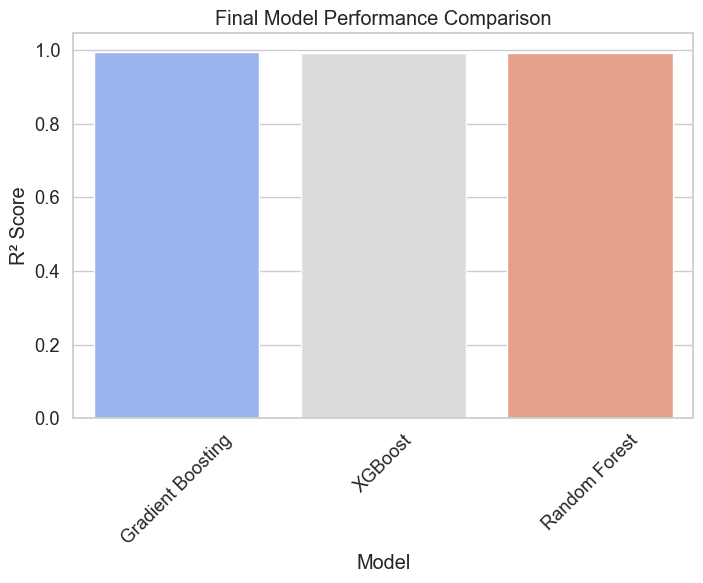

In [44]:
plt.figure(figsize=(8, 5))
sns.barplot(data=df_results, x="Model", y="R² Score", palette="coolwarm")
plt.xticks(rotation=45)
plt.title("Final Model Performance Comparison")
plt.show()

**Check for Overfitting:**

Since all models have very high R² scores (close to 1), they might be overfitting. Compare their performance on the training set:

In [45]:
train_results = {name: r2_score(y_train, model.predict(X_train)) for name, model in final_models.items()}
df_train_results = pd.DataFrame(train_results.items(), columns=["Model", "Train R² Score"]).sort_values(by="Train R² Score", ascending=False)
df_train_results

,Model,Train R² Score
1,Gradient Boosting,0.996839
0,Random Forest,0.995830
2,XGBoost,0.993639


In [47]:
test_results = {name: r2_score(y_test, model.predict(X_test)) for name, model in final_models.items()}
df_test_results = pd.DataFrame(test_results.items(), columns=["Model", "Test R² Score"]).sort_values(by="Test R² Score", ascending=False)
df_test_results


,Model,Test R² Score
1,Gradient Boosting,0.995017
2,XGBoost,0.991503
0,Random Forest,0.991211


- There is no major overfitting, as train and test scores are quite close.
- Gradient Boosting has the highest test R² (0.9950), but the differences are very small.

**Compare other metrics:**

R² alone doesn’t always tell the full story. Try Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE):

In [48]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

results = {}
for name, model in final_models.items():
    y_pred = model.predict(X_test)
    results[name] = {
        "R² Score": r2_score(y_test, y_pred),
        "MAE": mean_absolute_error(y_test, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred))
    }

df_results = pd.DataFrame.from_dict(results, orient="index").sort_values(by="R² Score", ascending=False)
df_results

,R² Score,MAE,RMSE
Gradient Boosting,0.995017,8.082869,23.575548
XGBoost,0.991503,10.304475,30.785043
Random Forest,0.991211,6.755596,31.309242


Mean Absolute Error (MAE):
- Random Forest has the lowest MAE (6.75), meaning it makes the smallest average error in predictions.
- XGBoost has the highest MAE (10.30), which might indicate more frequent larger errors.

Root Mean Squared Error (RMSE):
- RMSE penalizes large errors more than MAE.
- Random Forest has the lowest RMSE (31.30), followed by Gradient Boosting.
- XGBoost has the highest RMSE (30.78), meaning it may produce larger errors than the others.

**Which Model to Choose?**

- If you prioritize accuracy **(R²)**: `Gradient Boosting` is best.
- If you want **fewer large errors**: `Random Forest` has the _lowest MAE and RMSE_.
- If you need **speed & efficiency**: `Random Forest` is often _faster_ than `Gradient Boosting/XGBoost`.

Given the trade-offs, `Random Forest` appears to be the best overall choice due to its balance of accuracy, lower error rates, and stability.

### 7. Save the Best Model

In [49]:
# Define the save path
save_path = "C:/Users/haiho/GITHUB/Sydney-Airbnb-prices-prediction/results"
os.makedirs(save_path, exist_ok=True)  # Ensure the directory exists

In [52]:
df_results

,R² Score,MAE,RMSE
Gradient Boosting,0.995017,8.082869,23.575548
XGBoost,0.991503,10.304475,30.785043
Random Forest,0.991211,6.755596,31.309242


In [ ]:
# Save the best model
best_model_name = df_results.index[0]         # Get the best model name
best_model = final_models[best_model_name]    # Get the best model object

In [ ]:
best_model_name = df_results.iloc[0]["Model"]
best_model = final_models[best_model_name]
joblib.dump(best_model, f"results/best_model.pkl")

In [ ]:
# Define the save path
save_path = "C:/Users/haiho/GITHUB/Sydney-Airbnb-prices-prediction/results"
os.makedirs(save_path, exist_ok=True)  # Ensure the directory exists

# Save the best model
best_model_name = results_df.index[0]  # Get the best model name
best_model = models[best_model_name]   # Get the best model object

file_name = f"best_pipeline_{best_model_name}.pkl"
file_path = os.path.join(save_path, file_name)
joblib.dump(best_model, file_path)

print(f"Best model '{best_model_name}' saved successfully at: {file_path}")

In [ ]:
print(f"\n✅ Best model saved: {best_model_name}")

### 8. Generate Predictions

In [ ]:
# Make predictions
predictions = best_model.predict(df_test)

# Save predictions to CSV
df_test["Predicted_Price"] = predictions
predictions_file_path = "/mnt/data/test_predictions.csv"
df_test.to_csv(predictions_file_path, index=False)

In [ ]:
# Define a faster model setup
models = {
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "XGBoost": xgb.XGBRegressor(random_state=42)
}

param_distributions = {
    "Random Forest": {
        "model__n_estimators": [100, 200, 300],
        "model__max_depth": [10, 15, 20],
        "model__min_samples_split": [2, 5, 10],
    },
    "Gradient Boosting": {
        "model__n_estimators": [100, 200, 300],
        "model__learning_rate": [0.01, 0.05, 0.1],
        "model__max_depth": [3, 4, 5],
    },
    "XGBoost": {
        "model__n_estimators": [100, 200, 300],
        "model__learning_rate": [0.01, 0.05, 0.1],
        "model__max_depth": [3, 4, 5],
    }
}

# Train models
model_results = {}

for model_name, model in models.items():
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('model', model)
    ])

    opt = RandomizedSearchCV(pipeline, param_distributions[model_name], n_iter=10, cv=3, scoring="r2", random_state=42, n_jobs=-1)
    opt.fit(X_train, y_train)
    best_pipeline = opt.best_estimator_
    
    # Compute evaluation metrics
    y_pred = best_pipeline.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    rmse = mean_squared_error(y_test, y_pred, squared=False)
    mae = mean_absolute_error(y_test, y_pred)
    mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100  # Mean Absolute Percentage Error
    
    model_results[model_name] = {"R²": r2, "RMSE": rmse, "MAE": mae, "MAPE": mape}


# Convert results to DataFrame
results_df = pd.DataFrame(model_results).T.sort_values(by="R2 Score", ascending=False)
print("Model Performance Comparison:")
display(results_df)

# Define the save path
save_path = "C:/Users/haiho/GITHUB/Sydney-Airbnb-prices-prediction/results"
os.makedirs(save_path, exist_ok=True)  # Ensure the directory exists

# Save the best model
best_model_name = results_df.index[0]  # Get the best model name
best_model = models[best_model_name]   # Get the best model object

file_name = f"best_pipeline_{best_model_name}.pkl"
file_path = os.path.join(save_path, file_name)
joblib.dump(best_model, file_path)

print(f"Best model '{best_model_name}' saved successfully at: {file_path}")


# Visualization
plt.figure(figsize=(10,5))
sns.barplot(x=results_df.index, y=results_df["R2 Score"], palette="viridis")
plt.xticks(rotation=45)
plt.ylabel("R² Score")
plt.title("Model Performance Comparison")
plt.show()




# # Load the best model pipeline
# best_model_file = f"/mnt/data/best_pipeline_{results_df.index[0]}.pkl"
# best_pipeline = joblib.load(best_model_file)

# Make predictions
predictions = best_model.predict(df_test)

# Save predictions to CSV
df_test["Predicted_Price"] = predictions
predictions_file_path = "/mnt/data/test_predictions.csv"
df_test.to_csv(predictions_file_path, index=False)

# Return the path for download
predictions_file_path
